In [1]:
from matplotlib import font_manager
import matplotlib.pyplot as plt

fname = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"

font_manager.fontManager.addfont(fname)

prop = font_manager.FontProperties(fname=fname)
family_name = prop.get_name()

plt.rcParams["font.family"] = family_name

In [2]:
dir_root = "/home/zby/scMM/data/wholebody/identifications"

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

file_list = list(Path(dir_root).glob("*.csv"))
class_list, compound_list = {}, {}
for file in file_list:
    df = pd.read_csv(file)
    compound_list[file.stem], idx = np.unique(df["Accepted Description"].values, return_index=True)
    class_list[file.stem] = df["class"].fillna("Other").values[idx]
class_list.keys()

dict_keys(['Paramecium', 'Volvox', 'C. elegans', 'B. plicatilis'])

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values

<Figure size 1000x600 with 0 Axes>

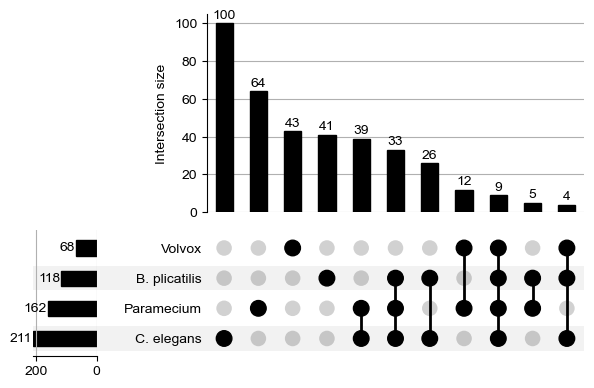

In [4]:
from upsetplot import UpSet, from_indicators
species_sets = {
    species: set(classes)
    for species, classes in compound_list.items()
}

all_classes = sorted(set().union(*species_sets.values()))
df = pd.DataFrame(
    {
        species: [lipid_class in species_sets[species] for lipid_class in all_classes]
        for species in species_sets
    },
    index=all_classes
)

upset_data = from_indicators(df.columns.tolist(), data=df)

plt.figure(figsize=(10,6))
upset = UpSet(
    upset_data,
    subset_size="count",
    show_counts=True,
    sort_by="cardinality"
)

upset.plot()

df.to_csv("/home/zby/scMM/data/wholebody/identifications/results/lipid_class_presence.csv")
plt.savefig("/home/zby/scMM/data/wholebody/identifications/results/upset_plot.svg", dpi=300, bbox_inches="tight")

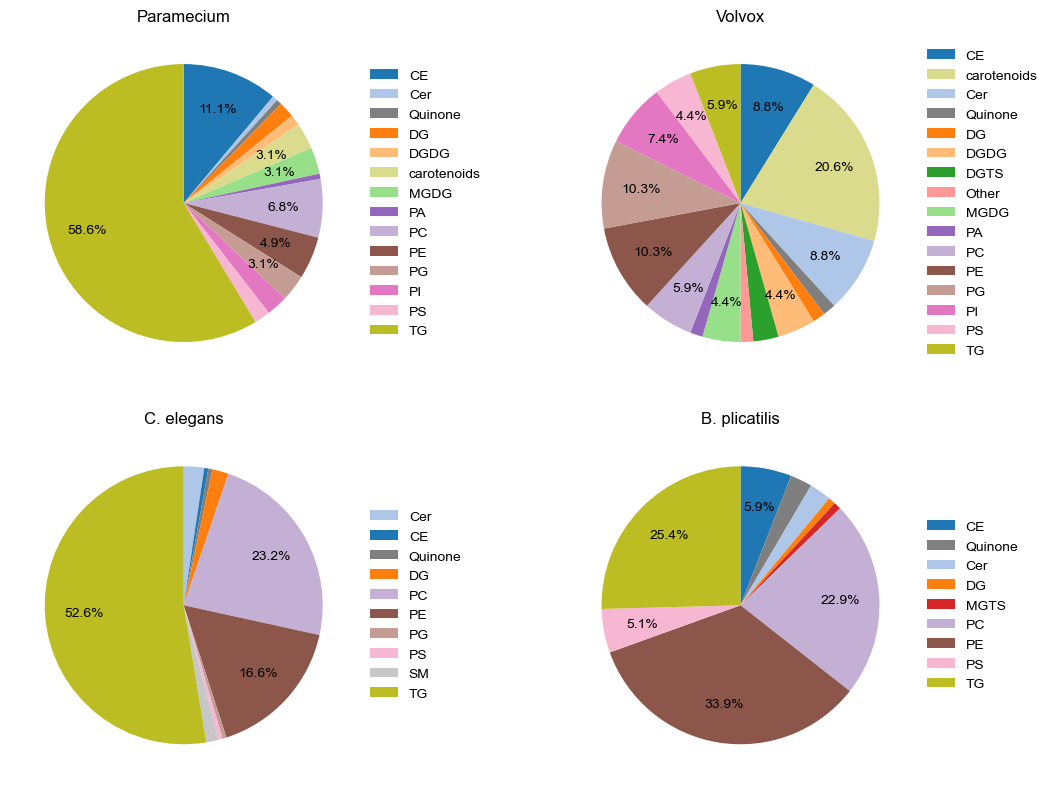

In [5]:
from collections import Counter
all_classes = []
for lipids in class_list.values():
    all_classes.extend(lipids)
all_classes = sorted(set(all_classes))

cmap_list = []
for cmap_name in ["tab20", "tab20b", "tab20c"]:
    cmap = plt.get_cmap(cmap_name)
    cmap_list.extend([cmap(i) for i in range(cmap.N)])

color_map = {cls: cmap_list[i] for i, cls in enumerate(all_classes)}
pct_threshold = 3

def autopct_func(pct):
    return f"{pct:.1f}%" if pct >= pct_threshold else ""

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (sp, lipids) in zip(axes.ravel(), class_list.items()):
    c = Counter(lipids)
    labels = list(c.keys())
    sizes = list(c.values())
    colors = [color_map[k] for k in labels]

    wedges, _, _ = ax.pie(
        sizes,
        labels=None,
        colors=colors,
        autopct=autopct_func,
        startangle=90,
        counterclock=False,
        pctdistance=0.72
    )

    ax.legend(
        wedges, labels,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=False
    )
    ax.set_title(sp)

plt.tight_layout()
plt.savefig("/home/zby/scMM/data/wholebody/identifications/results/lipid_class_distribution.svg", dpi=300, bbox_inches="tight")

In [6]:
target_lipid = ["DGTS 34:3", "PC 40:10", "TG 51:3", "PC 36:4"]
lipid_intensity = np.zeros((len(target_lipid), len(file_list)))

for k, file in enumerate(file_list):
    df = pd.read_csv(file)
    sample_col_pattern = ["WT-*", "daf-2-*", "elo-1-*", "Brachionus plicatilis-*", "Volvox-*", "Paramecium-*"]
    pattern = "|".join(sample_col_pattern)

    sample_cols = df.columns[df.columns.str.match(pattern)]

    for i, lipid in enumerate(target_lipid):
        sub = df.loc[df["Accepted Description"] == lipid, sample_cols]
        if not sub.empty:
            lipid_intensity[i, k] = sub.sum(axis=0).mean()
            
np.log10(lipid_intensity + 1)

array([[0.        , 4.50716016, 0.        , 0.        ],
       [0.        , 0.        , 5.0073656 , 0.        ],
       [4.09680256, 0.        , 5.20971583, 0.        ],
       [3.23431783, 0.        , 4.87576616, 3.92249321]])

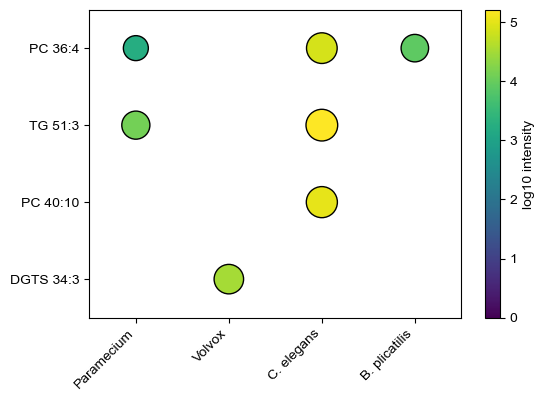

In [ ]:
lipid_intensity = np.log10(lipid_intensity + 1)
n_row, n_col = lipid_intensity.shape
x, y = np.meshgrid(np.arange(n_col), np.arange(n_row))

plt.figure(figsize=(6, 4))

plt.scatter(
    x.ravel(),
    y.ravel(),
    s=lipid_intensity.ravel() * 100, 
    c=lipid_intensity.ravel(), 
    cmap="viridis",
    edgecolors="black"
)

plt.xlim(-0.5, n_col - 0.5)
plt.ylim(n_row - 0.5, -0.5)
plt.xticks(np.arange(n_col), [file.stem for file in file_list], rotation=45, ha="right")
plt.yticks(np.arange(n_row), target_lipid)
plt.gca().invert_yaxis()
plt.colorbar(label="log10 intensity")
plt.savefig("/home/zby/scMM/data/wholebody/identifications/results/lipid_intensity_bubble_plot.svg", dpi=300, bbox_inches="tight")